# Final Results Tables and Figures

This notebook is an artifact reader for the final paper-facing results. It reads saved CSV/parquet files from `data/results/`, applies lightweight ordering and formatting, writes clean final CSV artifacts, and saves publication-ready figures under `data/results/figures/`.

It does not train models, recompute predictions, or overwrite frozen baseline artifacts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RESULTS = ROOT / "data" / "results"
FIGURES = RESULTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

FINAL_ROSTER = [
    "HAR per-stock",
    "HAR pooled",
    "LSTM",
    "GNN-Correlation",
    "GNN-Sector",
    "GNN-Granger",
    "GNN-Ensemble",
    "GNN-Correlation + Macro Tuned",
    "GNN-Correlation + Macro 21d",
    "GNN-Correlation + Macro 63d",
    "GNN-Correlation + Macro 126d",
    "GNN-Sector + Macro",
    "GNN-Granger + Macro",
    "GNN-Ensemble + Macro",
]

EXPLORATORY_MODELS = [
    "GNN-Correlation + Macro",
    "LSTM + Macro",
]

PORTFOLIO_ROSTER = FINAL_ROSTER + ["Equal-weight"]

FOCUSED_CALIBRATION_MODELS = [
    "HAR per-stock",
    "LSTM",
    "GNN-Correlation",
    "GNN-Correlation + Macro Tuned",
    "GNN-Correlation + Macro 21d",
    "GNN-Correlation + Macro 63d",
    "GNN-Correlation + Macro 126d",
    "GNN-Sector + Macro",
    "GNN-Granger + Macro",
]

FOCUSED_PORTFOLIO_MODELS = [
    "Equal-weight",
    "HAR per-stock",
    "LSTM",
    "GNN-Ensemble",
    "GNN-Correlation + Macro Tuned",
    "GNN-Correlation + Macro 21d",
    "GNN-Correlation + Macro 63d",
    "GNN-Correlation + Macro 126d",
    "GNN-Ensemble + Macro",
]

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


def read_csv(name):
    path = RESULTS / name
    if not path.exists():
        raise FileNotFoundError(f"Missing required artifact: {path}")
    return pd.read_csv(path)


def ordered(df, roster, model_col="model"):
    out = df[df[model_col].isin(roster)].copy()
    order = {name: i for i, name in enumerate(roster)}
    out["_order"] = out[model_col].map(order)
    out = out.sort_values("_order").drop(columns="_order")
    return out


def save_final(df, name):
    path = RESULTS / name
    df.to_csv(path, index=False)
    return path


def rounded(df, decimals=4):
    out = df.copy()
    numeric_cols = out.select_dtypes(include=["number"]).columns
    out[numeric_cols] = out[numeric_cols].round(decimals)
    return out


def display_table(title, df, decimals=4):
    display(Markdown(f"### {title}"))
    display(rounded(df, decimals))


def model_colors(models):
    colors = []
    for model in models:
        if "Macro" in model:
            colors.append("#2f7d59")
        elif model == "Equal-weight":
            colors.append("#6b7280")
        elif model.startswith("HAR"):
            colors.append("#4c78a8")
        elif model == "LSTM":
            colors.append("#b279a2")
        else:
            colors.append("#f58518")
    return colors


def horizontal_bar(df, x_col, y_col, title, xlabel, path, value_fmt="{:.4f}"):
    plot_df = df[[y_col, x_col]].dropna().copy()
    plot_df = plot_df.iloc[::-1]
    fig, ax = plt.subplots(figsize=(8.2, 5.2))
    bars = ax.barh(
        plot_df[y_col],
        plot_df[x_col],
        color=model_colors(plot_df[y_col]),
        alpha=0.92,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    for bar, value in zip(bars, plot_df[x_col]):
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            "  " + value_fmt.format(value),
            va="center",
            fontsize=8,
        )
    ax.margins(x=0.12)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return path


print(f"Reading artifacts from: {RESULTS}")
print(f"Saving figures to: {FIGURES}")

Reading artifacts from: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results
Saving figures to: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\figures


## 1. ML Metrics

The headline ML table is restricted to the final model roster. Exploratory variants such as untuned `GNN-Correlation + Macro` and `LSTM + Macro` are not included in this main table.

In [2]:
ml_metrics = read_csv("ml_metrics_table.csv")
final_ml = ordered(ml_metrics, FINAL_ROSTER)[["model", "mse", "mae", "r2", "da"]]
ml_path = save_final(final_ml, "final_ml_metrics_table.csv")
display_table("Final ML Metrics", final_ml)
print(f"Saved: {ml_path.relative_to(ROOT)}")

### Final ML Metrics

,model,mse,mae,r2,da
10,HAR per-stock,0.0329,0.1129,0.1307,0.7070
11,HAR pooled,0.0331,0.1133,0.1242,0.7030
9,LSTM,0.0324,0.1096,0.1422,0.7088
8,GNN-Correlation,0.0322,0.1076,0.1484,0.7122
13,GNN-Sector,0.0336,0.1208,0.1102,0.6822
14,GNN-Granger,0.0337,0.1190,0.1084,0.6879
6,GNN-Ensemble,0.0320,0.1127,0.1531,0.7004
1,GNN-Correlation + Macro Tuned,0.0309,0.1070,0.1828,0.7197
0,GNN-Correlation + Macro 21d,0.0296,0.1024,0.2175,0.7283
7,GNN-Correlation + Macro 63d,0.0322,0.1063,0.1484,0.7215


Saved: data\results\final_ml_metrics_table.csv


Point-estimate test MSE is lowest for `GNN-Correlation + Macro Tuned` in the saved artifacts. This table should be interpreted with the formal weekly DM tests below rather than as standalone evidence that one model family dominates all baselines.

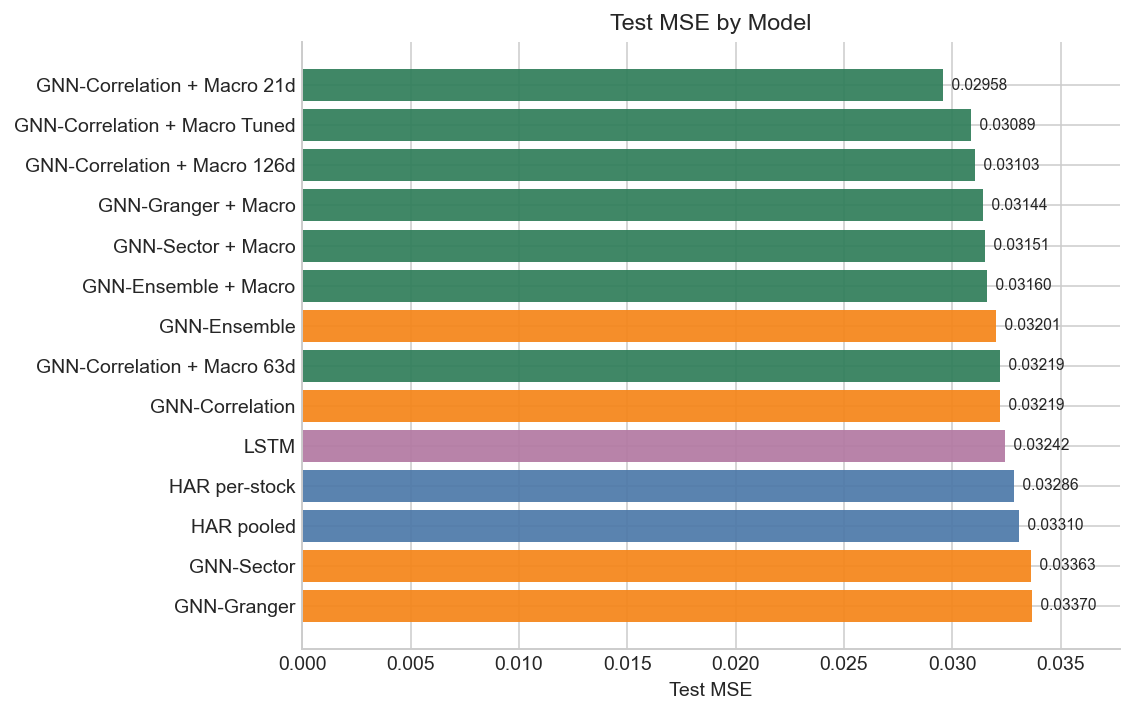

Saved: data\results\figures\final_test_mse_by_model.png


In [3]:
mse_fig = horizontal_bar(
    final_ml.sort_values("mse", ascending=True),
    x_col="mse",
    y_col="model",
    title="Test MSE by Model",
    xlabel="Test MSE",
    path=FIGURES / "final_test_mse_by_model.png",
    value_fmt="{:.5f}",
)
print(f"Saved: {mse_fig.relative_to(ROOT)}")

## 2. Rank IC / ICIR

Rank metrics evaluate whether models correctly order stocks by next-week realized volatility. The table includes hit-rate and pairwise-accuracy columns when present in the saved artifact.

In [4]:
rank_ic = read_csv("rank_ic_table.csv")
rank_cols = ["model", "mean_ic", "ic_ir"]
for optional in ["pct_positive", "top_quartile_hit_rate", "pairwise_accuracy"]:
    if optional in rank_ic.columns:
        rank_cols.append(optional)
final_rank = ordered(rank_ic, FINAL_ROSTER)[rank_cols]
rank_path = save_final(final_rank, "final_rank_ic_table.csv")
display_table("Final Rank IC Metrics", final_rank)
print(f"Saved: {rank_path.relative_to(ROOT)}")

### Final Rank IC Metrics

,model,mean_ic,ic_ir,pct_positive,top_quartile_hit_rate,pairwise_accuracy
12,HAR per-stock,0.4049,3.4728,1.0,0.4859,0.6407
13,HAR pooled,0.3923,3.4370,1.0,0.4784,0.6355
5,LSTM,0.4288,4.3626,1.0,0.4990,0.6484
10,GNN-Correlation,0.4165,3.4399,1.0,0.4919,0.6448
14,GNN-Sector,0.3826,3.3994,1.0,0.4787,0.6330
15,GNN-Granger,0.3749,3.6630,1.0,0.4726,0.6293
11,GNN-Ensemble,0.4162,3.5769,1.0,0.4936,0.6451
6,GNN-Correlation + Macro Tuned,0.4286,3.6803,1.0,0.5023,0.6491
3,GNN-Correlation + Macro 21d,0.4312,4.0371,1.0,0.5028,0.6498
8,GNN-Correlation + Macro 63d,0.4219,3.7577,1.0,0.4963,0.6468


Saved: data\results\final_rank_ic_table.csv


Rank IC and ICIR measure a different objective than MSE. Stronger ranking does not automatically imply better calibrated volatility levels or better portfolio behavior.

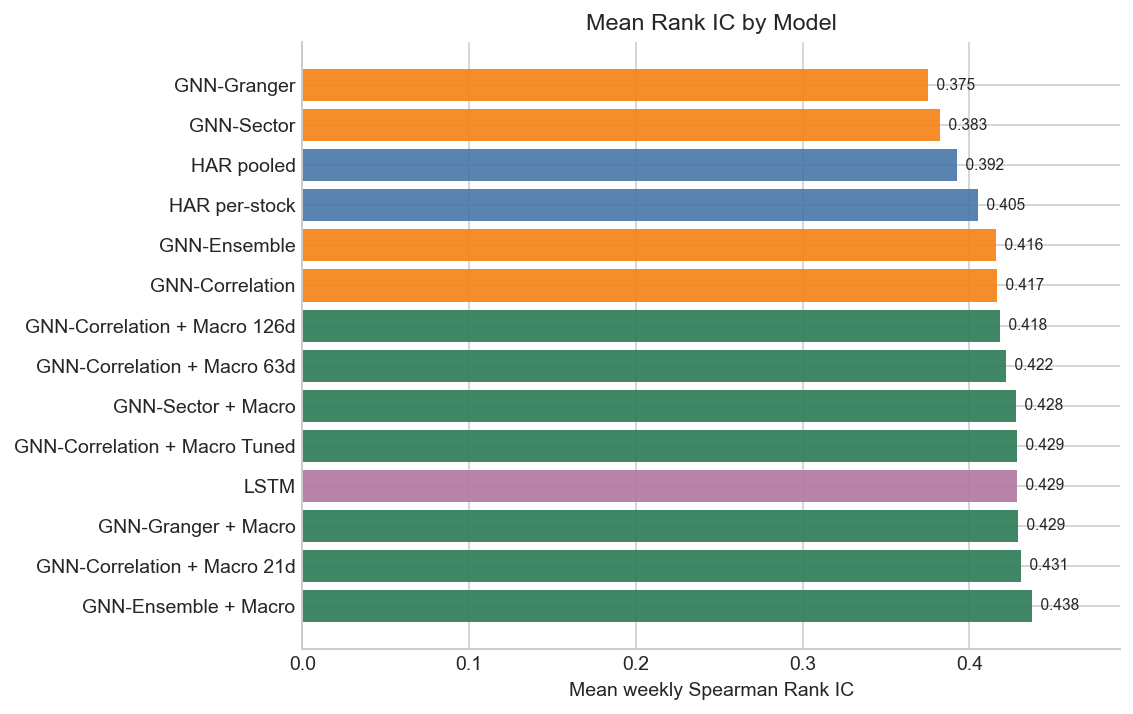

Saved: data\results\figures\final_rank_ic_by_model.png


In [5]:
rank_fig = horizontal_bar(
    final_rank.sort_values("mean_ic", ascending=True),
    x_col="mean_ic",
    y_col="model",
    title="Mean Rank IC by Model",
    xlabel="Mean weekly Spearman Rank IC",
    path=FIGURES / "final_rank_ic_by_model.png",
    value_fmt="{:.3f}",
)
print(f"Saved: {rank_fig.relative_to(ROOT)}")

## 3. Calibration

Calibration summaries and decile plots show whether predicted volatility levels line up with realized volatility levels. This matters for inverse-volatility and minimum-variance portfolio construction.

In [6]:
calibration = read_csv("calibration_summary.csv")
calibration_bins = read_csv("calibration_bins.csv")
cal_cols = [
    "model",
    "calibration_slope",
    "calibration_intercept",
    "pearson_corr",
    "prediction_mean",
    "prediction_std",
    "prediction_min",
    "prediction_max",
    "avg_weekly_prediction_spread_p90_p10",
]
final_calibration = ordered(calibration, FINAL_ROSTER)[cal_cols]
cal_path = save_final(final_calibration, "final_calibration_summary.csv")
display_table("Final Calibration Summary", final_calibration)
print(f"Saved: {cal_path.relative_to(ROOT)}")

### Final Calibration Summary

,model,calibration_slope,calibration_intercept,pearson_corr,prediction_mean,prediction_std,prediction_min,prediction_max,avg_weekly_prediction_spread_p90_p10
12,HAR per-stock,0.7452,0.0637,0.3847,0.2538,0.1004,0.0643,3.1389,0.2017
13,HAR pooled,0.7429,0.0642,0.3756,0.2539,0.0983,0.1001,2.2918,0.1799
14,LSTM,0.9297,0.0231,0.3793,0.2471,0.0793,0.0858,1.9006,0.1673
0,GNN-Correlation,1.1827,-0.0251,0.4007,0.2350,0.0659,0.0929,0.8642,0.1325
10,GNN-Sector,0.9324,-0.0052,0.3550,0.2767,0.0740,0.0341,0.7675,0.1642
8,GNN-Granger,0.8731,0.0169,0.3448,0.2702,0.0768,0.1358,0.8644,0.1564
6,GNN-Ensemble,1.1581,-0.0475,0.3964,0.2594,0.0665,0.1218,0.7485,0.1410
5,GNN-Correlation + Macro Tuned,0.7678,0.0628,0.4495,0.2475,0.1138,0.0938,1.7943,0.1644
3,GNN-Correlation + Macro 21d,1.0992,-0.0012,0.4816,0.2311,0.0852,0.0911,2.0121,0.1325
4,GNN-Correlation + Macro 63d,0.6806,0.0948,0.4526,0.2321,0.1293,0.0681,3.4386,0.1451


Saved: data\results\final_calibration_summary.csv


A well-ranked model can still be poorly calibrated if its slope, intercept, or prediction spread are distorted. The final narrative should keep ranking and level calibration separate.

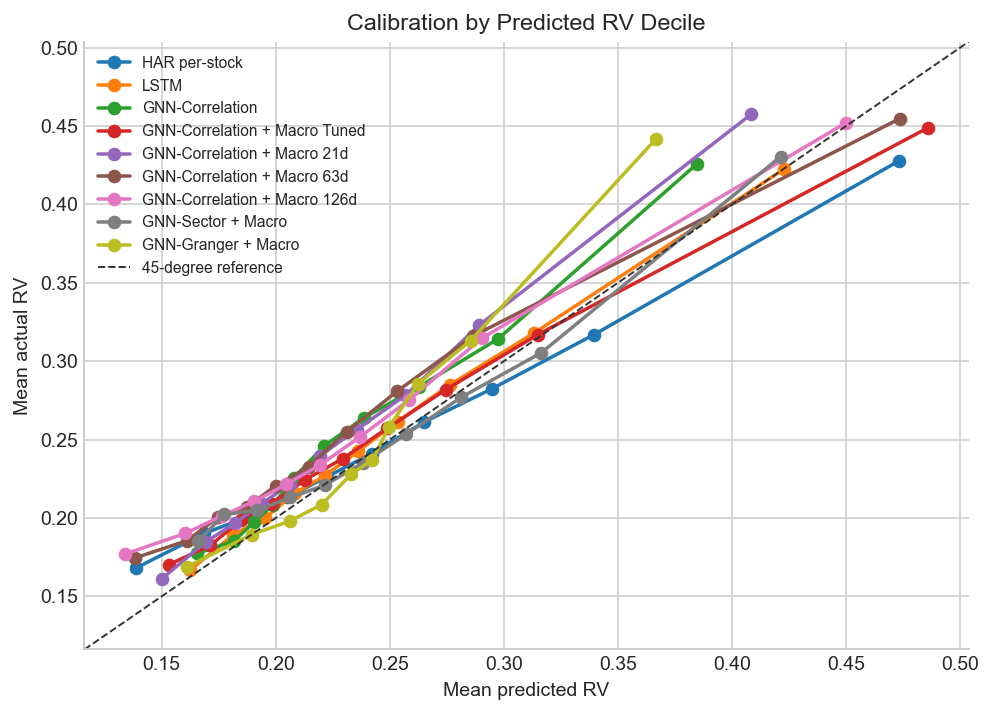

Saved: data\results\figures\final_calibration_by_predicted_rv.png


In [7]:
plot_bins = calibration_bins[
    calibration_bins["model"].isin(FOCUSED_CALIBRATION_MODELS)
].copy()
fig, ax = plt.subplots(figsize=(7.2, 5.2))
for model in FOCUSED_CALIBRATION_MODELS:
    model_bins = plot_bins[plot_bins["model"] == model].sort_values("decile")
    if model_bins.empty:
        continue
    ax.plot(
        model_bins["predicted_rv_mean"],
        model_bins["actual_rv_mean"],
        marker="o",
        linewidth=1.8,
        label=model,
    )
lims = [
    min(plot_bins["predicted_rv_mean"].min(), plot_bins["actual_rv_mean"].min()),
    max(plot_bins["predicted_rv_mean"].max(), plot_bins["actual_rv_mean"].max()),
]
pad = (lims[1] - lims[0]) * 0.05
lims = [lims[0] - pad, lims[1] + pad]
ax.plot(
    lims,
    lims,
    color="#333333",
    linestyle="--",
    linewidth=1,
    label="45-degree reference",
)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title("Calibration by Predicted RV Decile")
ax.set_xlabel("Mean predicted RV")
ax.set_ylabel("Mean actual RV")
ax.legend(frameon=False, fontsize=8, loc="best")
fig.tight_layout()
cal_fig = FIGURES / "final_calibration_by_predicted_rv.png"
fig.savefig(cal_fig, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved: {cal_fig.relative_to(ROOT)}")

## 4. Portfolio Metrics

These tables summarize the saved portfolio evaluations by strategy. Equal-weight is retained where it exists as a strategy benchmark.

In [8]:
portfolio_specs = [
    (
        "Inverse-Volatility",
        "portfolio_metrics_table.csv",
        "final_portfolio_inverse_vol_metrics.csv",
        PORTFOLIO_ROSTER,
    ),
    (
        "Long-Short",
        "portfolio_ls_metrics_table.csv",
        "final_portfolio_long_short_metrics.csv",
        FINAL_ROSTER,
    ),
    (
        "Volatility-Targeted",
        "portfolio_vt_metrics_table.csv",
        "final_portfolio_vol_target_metrics.csv",
        FINAL_ROSTER,
    ),
    (
        "Minimum-Variance",
        "portfolio_mv_metrics_table.csv",
        "final_portfolio_minvar_metrics.csv",
        FINAL_ROSTER,
    ),
]
final_portfolio_tables = {}
for title, source, output, roster in portfolio_specs:
    df = read_csv(source)
    cols = [
        c
        for c in [
            "model",
            "ann_return",
            "ann_vol",
            "sharpe",
            "max_drawdown",
            "avg_turnover",
            "max_single_stock_weight",
            "max_long_weight",
            "avg_equity_weight",
        ]
        if c in df.columns
    ]
    final_df = ordered(df, roster)[cols]
    final_portfolio_tables[title] = final_df
    out_path = save_final(final_df, output)
    display_table(f"Final Portfolio Metrics: {title}", final_df)
    print(f"Saved: {out_path.relative_to(ROOT)}")

### Final Portfolio Metrics: Inverse-Volatility

,model,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover,max_single_stock_weight
0,HAR per-stock,0.0999,0.1261,0.3956,-0.1548,0.1634,0.0077
1,HAR pooled,0.1018,0.1276,0.4060,-0.1586,0.1521,0.0049
2,LSTM,0.1021,0.1267,0.4111,-0.1580,0.0758,0.0057
4,GNN-Correlation,0.0994,0.1277,0.3869,-0.1592,0.0787,0.0050
10,GNN-Sector,0.1027,0.1287,0.4097,-0.1573,0.0719,0.0161
12,GNN-Granger,0.1046,0.1290,0.4234,-0.1604,0.0818,0.0039
14,GNN-Ensemble,0.1035,0.1283,0.4168,-0.1586,0.0581,0.0040
6,GNN-Correlation + Macro Tuned,0.1031,0.1249,0.4251,-0.1510,0.0902,0.0081
7,GNN-Correlation + Macro 21d,0.1043,0.1270,0.4275,-0.1564,0.0849,0.0056
8,GNN-Correlation + Macro 63d,0.1001,0.1259,0.3980,-0.1534,0.0987,0.0076


Saved: data\results\final_portfolio_inverse_vol_metrics.csv


### Final Portfolio Metrics: Long-Short

,model,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover,max_long_weight
0,HAR per-stock,-0.1686,0.1621,-1.3492,-0.3587,1.3298,0.0086
1,HAR pooled,-0.1919,0.1528,-1.5828,-0.3604,1.4774,0.0086
2,LSTM,-0.1565,0.1650,-1.2518,-0.3550,0.7648,0.0086
4,GNN-Correlation,-0.2644,0.1768,-1.7786,-0.4248,0.9674,0.0086
10,GNN-Sector,-0.1705,0.1750,-1.2594,-0.3684,0.7861,0.0086
12,GNN-Granger,-0.1550,0.1568,-1.3075,-0.3443,0.9829,0.0086
14,GNN-Ensemble,-0.1849,0.1819,-1.2913,-0.3927,0.7201,0.0086
6,GNN-Correlation + Macro Tuned,-0.1794,0.1909,-1.2016,-0.3703,0.8420,0.0086
7,GNN-Correlation + Macro 21d,-0.1860,0.1781,-1.3245,-0.3744,0.9615,0.0086
8,GNN-Correlation + Macro 63d,-0.2177,0.1763,-1.5182,-0.3752,1.0266,0.0086


...

,model,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover,max_single_stock_weight,avg_equity_weight
0,HAR per-stock,0.0384,0.0530,-0.2193,-0.0670,0.0763,0.0032,0.4333
1,HAR pooled,0.0388,0.0538,-0.2077,-0.0686,0.0734,0.0021,0.4364
2,LSTM,0.0437,0.0554,-0.1140,-0.0711,0.0335,0.0024,0.4373
4,GNN-Correlation,0.0385,0.0594,-0.1928,-0.0756,0.0523,0.0024,0.4646
10,GNN-Sector,0.0392,0.0489,-0.2196,-0.0611,0.0281,0.0062,0.3813
12,GNN-Granger,0.0397,0.0513,-0.1998,-0.0661,0.0369,0.0016,0.3996
14,GNN-Ensemble,0.0396,0.0528,-0.1964,-0.0673,0.0295,0.0018,0.4130
6,GNN-Correlation + Macro Tuned,0.0300,0.0556,-0.3586,-0.0682,0.0661,0.0023,0.4494
7,GNN-Correlation + Macro 21d,0.0398,0.0562,-0.1824,-0.0678,0.0604,0.0023,0.4701
8,GNN-Correlation + Macro 63d,0.0342,0.0613,-0.2580,-0.0750,0.0800,0.0029,0.4882


Saved: data\results\final_portfolio_vol_target_metrics.csv


### Final Portfolio Metrics: Minimum-Variance

,model,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover,max_single_stock_weight
0,HAR per-stock,0.1126,0.0986,0.6346,-0.1273,1.0121,0.05
1,HAR pooled,0.1245,0.1021,0.7289,-0.1189,0.9135,0.05
2,LSTM,0.1118,0.1096,0.5637,-0.1141,0.5914,0.05
4,GNN-Correlation,0.1183,0.1175,0.5814,-0.1276,0.6060,0.05
10,GNN-Sector,0.1043,0.1104,0.4918,-0.0891,0.5329,0.05
12,GNN-Granger,0.0963,0.1123,0.4119,-0.1296,0.6760,0.05
14,GNN-Ensemble,0.1059,0.1122,0.4977,-0.1084,0.4915,0.05
6,GNN-Correlation + Macro Tuned,0.1175,0.1005,0.6711,-0.0856,0.7700,0.05
7,GNN-Correlation + Macro 21d,0.1132,0.1034,0.6114,-0.0999,0.7060,0.05
8,GNN-Correlation + Macro 63d,0.0728,0.1023,0.2234,-0.1111,0.8327,0.05


Saved: data\results\final_portfolio_minvar_metrics.csv


Portfolio outcomes depend on construction choices as well as forecast quality. The final paper should avoid treating a point-forecast win as equivalent to an investable performance win.

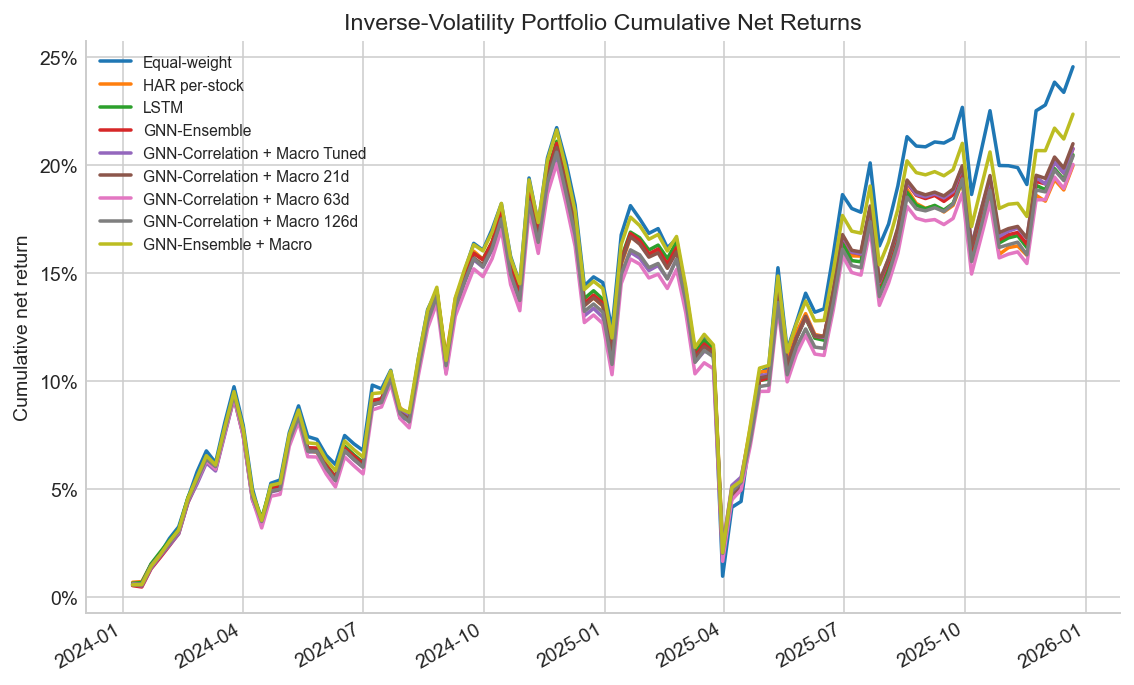

Saved: data\results\figures\final_portfolio_cumulative_returns.png


In [9]:
returns = pd.read_parquet(RESULTS / "portfolio_returns.parquet")
returns["week"] = pd.to_datetime(returns["week"])
plot_returns = returns[returns["model"].isin(FOCUSED_PORTFOLIO_MODELS)].copy()
plot_returns = plot_returns.sort_values(["model", "week"])
plot_returns["cum_net_return"] = plot_returns.groupby("model")[
    "net_return"
].transform(lambda s: (1 + s).cumprod() - 1)

fig, ax = plt.subplots(figsize=(8.2, 5.0))
for model in FOCUSED_PORTFOLIO_MODELS:
    model_returns = plot_returns[plot_returns["model"] == model]
    if model_returns.empty:
        continue
    ax.plot(
        model_returns["week"],
        model_returns["cum_net_return"],
        linewidth=1.8,
        label=model,
    )
ax.set_title("Inverse-Volatility Portfolio Cumulative Net Returns")
ax.set_xlabel("")
ax.set_ylabel("Cumulative net return")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend(frameon=False, fontsize=8, loc="best")
fig.autofmt_xdate()
fig.tight_layout()
portfolio_fig = FIGURES / "final_portfolio_cumulative_returns.png"
fig.savefig(portfolio_fig, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved: {portfolio_fig.relative_to(ROOT)}")

## 5. DM Tests

The Diebold-Mariano tests use weekly MSE series, where each weekly loss is averaged across stocks. This preserves the time-series structure of the forecast errors better than comparing only pooled scalar MSE values.

In [10]:
dm = read_csv("dm_test_results.csv")
macro_dm = read_csv("macro_dm_test_results.csv")

main_dm = dm[
    dm["model"].isin(FINAL_ROSTER)
    & dm["baseline"].isin(
        [
            "HAR per-stock",
            "LSTM",
            "GNN-Correlation",
            "GNN-Sector",
            "GNN-Granger",
            "GNN-Ensemble",
        ]
    )
].copy()
macro_dm_final = macro_dm[
    macro_dm["model"].isin(FINAL_ROSTER)
    | macro_dm["model"].isin(EXPLORATORY_MODELS)
].copy()
main_dm["test_group"] = "final_vs_baseline"
macro_dm_final["test_group"] = "macro_vs_matched_baseline"
final_dm = pd.concat([main_dm, macro_dm_final], ignore_index=True, sort=False)
final_dm = final_dm[
    [
        "test_group",
        "model",
        "baseline",
        "dm_stat",
        "p_value",
        "p_value_bh",
        "rejected_bh",
        "mean_loss_diff",
        "n_weeks",
    ]
]
final_dm = final_dm.sort_values(
    ["test_group", "p_value_bh", "model", "baseline"]
)
dm_path = save_final(final_dm, "final_dm_test_summary.csv")
display_table("Final DM Test Summary", final_dm, decimals=5)
print(f"Saved: {dm_path.relative_to(ROOT)}")

### Final DM Test Summary

,test_group,model,baseline,dm_stat,p_value,p_value_bh,rejected_bh,mean_loss_diff,n_weeks
0,final_vs_baseline,GNN-Correlation + Macro Tuned,HAR per-stock,3.22062,0.00086,0.01545,True,0.00197,103
3,final_vs_baseline,GNN-Correlation + Macro 126d,HAR per-stock,1.91887,0.02890,0.13004,False,0.00183,103
1,final_vs_baseline,GNN-Correlation + Macro 21d,HAR per-stock,2.17851,0.01584,0.13004,False,0.00328,103
2,final_vs_baseline,GNN-Granger + Macro,HAR per-stock,1.93868,0.02765,0.13004,False,0.00142,103
4,final_vs_baseline,GNN-Ensemble + Macro,HAR per-stock,1.74805,0.04173,0.13050,False,0.00126,103
5,final_vs_baseline,GNN-Sector + Macro,HAR per-stock,1.34491,0.09082,0.23353,False,0.00135,103
7,final_vs_baseline,GNN-Correlation,HAR per-stock,0.64615,0.25982,0.50379,False,0.00067,103
8,final_vs_baseline,GNN-Correlation + Macro 63d,HAR per-stock,0.58511,0.27988,0.50379,False,0.00067,103
6,final_vs_baseline,GNN-Ensemble,HAR per-stock,0.71667,0.23761,0.50379,False,0.00085,103
19,final_vs_baseline,GNN-Correlation,LSTM,0.39455,0.34700,0.62460,False,0.00023,103


Saved: data\results\final_dm_test_summary.csv


The statistical-test section should govern final performance claims. A macro point-estimate improvement should not be described as statistically significant unless the adjusted tests support that statement.

## 6. Bootstrap Sharpe Intervals

Sharpe intervals and Sharpe-difference intervals are read from saved block-bootstrap outputs. These use weekly portfolio return series rather than summary metrics alone.

In [11]:
bootstrap = read_csv("bootstrap_sharpe_ci.csv")
macro_bootstrap = read_csv("macro_bootstrap_sharpe_ci.csv")

boot_main = bootstrap[bootstrap["model"].isin(PORTFOLIO_ROSTER)].copy()
macro_boot = macro_bootstrap[
    macro_bootstrap["model"].isin(FINAL_ROSTER)
    | macro_bootstrap["model"].isin(EXPLORATORY_MODELS)
].copy()
boot_main["summary_type"] = "sharpe_interval"
macro_boot["summary_type"] = "macro_sharpe_difference"

boot_cols = [
    "summary_type",
    "strategy",
    "model",
    "benchmark",
    "baseline",
    "comparison",
    "point_estimate",
    "ci_lower",
    "ci_upper",
    "n_weeks",
    "block_size",
    "n_bootstrap",
]
for col in boot_cols:
    if col not in boot_main.columns:
        boot_main[col] = np.nan
    if col not in macro_boot.columns:
        macro_boot[col] = np.nan
final_bootstrap = pd.concat(
    [boot_main[boot_cols], macro_boot[boot_cols]], ignore_index=True
)
final_bootstrap = final_bootstrap.sort_values(
    ["summary_type", "strategy", "model", "comparison"]
)
boot_path = save_final(final_bootstrap, "final_bootstrap_sharpe_summary.csv")
display_table("Final Bootstrap Sharpe Summary", final_bootstrap, decimals=4)
print(f"Saved: {boot_path.relative_to(ROOT)}")

### Final Bootstrap Sharpe Summary

,summary_type,strategy,model,benchmark,baseline,comparison,point_estimate,ci_lower,ci_upper,n_weeks,block_size,n_bootstrap
71,macro_sharpe_difference,long_only_inverse_vol,GNN-Correlation + Macro,NaN,GNN-Correlation,macro_sharpe_diff,0.0655,0.0189,0.1173,103,8,5000
72,macro_sharpe_difference,long_only_inverse_vol,GNN-Correlation + Macro 126d,NaN,GNN-Correlation,macro_sharpe_diff,0.0315,-0.0225,0.0840,103,8,5000
73,macro_sharpe_difference,long_only_inverse_vol,GNN-Correlation + Macro 21d,NaN,GNN-Correlation,macro_sharpe_diff,0.0429,0.0063,0.0799,103,8,5000
74,macro_sharpe_difference,long_only_inverse_vol,GNN-Correlation + Macro 63d,NaN,GNN-Correlation,macro_sharpe_diff,0.0168,-0.0514,0.0712,103,8,5000
75,macro_sharpe_difference,long_only_inverse_vol,GNN-Correlation + Macro Tuned,NaN,GNN-Correlation,macro_sharpe_diff,0.0472,-0.0217,0.1099,103,8,5000
...,...,...,...,...,...,...,...,...,...,...,...,...
66,sharpe_interval,volatility_targeted,GNN-Sector,NaN,NaN,sharpe,0.8018,-0.2559,2.0643,103,8,5000
67,sharpe_interval,volatility_targeted,GNN-Sector + Macro,NaN,NaN,sharpe,0.7407,-0.3370,1.9444,103,8,5000
68,sharpe_interval,volatility_targeted,HAR per-stock,NaN,NaN,sharpe,0.7243,-0.3424,2.0052,103,8,5000
69,sharpe_interval,volatility_targeted,HAR pooled,NaN,NaN,sharpe,0.7217,-0.3466,2.0089,103,8,5000


Saved: data\results\final_bootstrap_sharpe_summary.csv


Sharpe intervals are wide over the available 103-week test window. The final discussion should distinguish economically meaningful point estimates from intervals that include zero or overlap materially.

## 7. Macro-vs-Baseline Deltas

This section is explicitly a macro comparison table. It includes the tuned macro correlation GNN and also keeps exploratory macro variants clearly separated from the main headline model tables.

In [12]:
macro_ml = read_csv("macro_ml_metric_deltas.csv")
macro_port = read_csv("macro_portfolio_metric_deltas.csv")

macro_ml_final = macro_ml[
    macro_ml["macro_model"].isin(FINAL_ROSTER + EXPLORATORY_MODELS)
].copy()
macro_ml_final["strategy"] = "ml_metrics"
macro_ml_final["delta_sharpe"] = np.nan
macro_ml_final["delta_ann_return"] = np.nan
macro_ml_final["delta_source"] = "ML"
macro_ml_view = macro_ml_final[
    [
        "delta_source",
        "strategy",
        "baseline_model",
        "macro_model",
        "delta_mse",
        "delta_mae",
        "delta_r2",
        "delta_da",
        "delta_ann_return",
        "delta_sharpe",
    ]
]

macro_port_final = macro_port[
    macro_port["macro_model"].isin(FINAL_ROSTER + EXPLORATORY_MODELS)
].copy()
macro_port_final["delta_mse"] = np.nan
macro_port_final["delta_mae"] = np.nan
macro_port_final["delta_r2"] = np.nan
macro_port_final["delta_da"] = np.nan
macro_port_final["delta_source"] = "Portfolio"
macro_port_view = macro_port_final[
    [
        "delta_source",
        "strategy",
        "baseline_model",
        "macro_model",
        "delta_mse",
        "delta_mae",
        "delta_r2",
        "delta_da",
        "delta_ann_return",
        "delta_sharpe",
    ]
]

final_macro_deltas = pd.concat([macro_ml_view, macro_port_view], ignore_index=True)
final_macro_deltas = final_macro_deltas.sort_values(
    ["delta_source", "strategy", "baseline_model", "macro_model"]
)
macro_delta_path = save_final(
    final_macro_deltas, "final_macro_vs_baseline_deltas.csv"
)
display_table("Final Macro-vs-Baseline Deltas", final_macro_deltas, decimals=5)
print(f"Saved: {macro_delta_path.relative_to(ROOT)}")

### Final Macro-vs-Baseline Deltas

,delta_source,strategy,baseline_model,macro_model,delta_mse,delta_mae,delta_r2,delta_da,delta_ann_return,delta_sharpe
1,ML,ml_metrics,GNN-Correlation,GNN-Correlation + Macro,0.00119,-0.00030,-0.03154,0.00420,NaN,NaN
5,ML,ml_metrics,GNN-Correlation,GNN-Correlation + Macro 126d,-0.00116,-0.00204,0.03073,0.00614,NaN,NaN
3,ML,ml_metrics,GNN-Correlation,GNN-Correlation + Macro 21d,-0.00262,-0.00527,0.06919,0.01610,NaN,NaN
4,ML,ml_metrics,GNN-Correlation,GNN-Correlation + Macro 63d,-0.00000,-0.00138,0.00009,0.00931,NaN,NaN
2,ML,ml_metrics,GNN-Correlation,GNN-Correlation + Macro Tuned,-0.00130,-0.00065,0.03445,0.00750,NaN,NaN
8,ML,ml_metrics,GNN-Ensemble,GNN-Ensemble + Macro,-0.00041,-0.00542,0.01094,0.01439,NaN,NaN
7,ML,ml_metrics,GNN-Granger,GNN-Granger + Macro,-0.00226,-0.01134,0.05987,0.02568,NaN,NaN
6,ML,ml_metrics,GNN-Sector,GNN-Sector + Macro,-0.00212,-0.01020,0.05618,0.02203,NaN,NaN
0,ML,ml_metrics,LSTM,LSTM + Macro,0.00242,0.01516,-0.06404,-0.03516,NaN,NaN
10,Portfolio,inverse_vol,GNN-Correlation,GNN-Correlation + Macro,NaN,NaN,NaN,NaN,0.01024,0.07217


Saved: data\results\final_macro_vs_baseline_deltas.csv


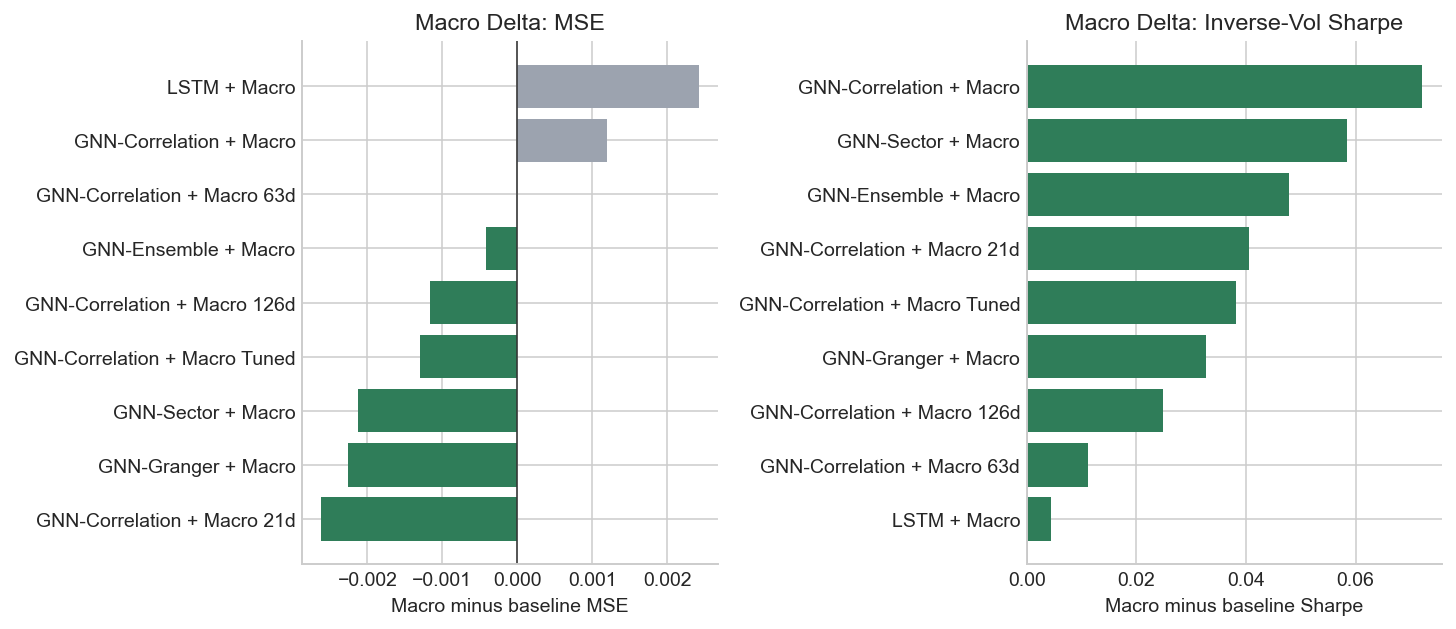

Saved: data\results\figures\final_macro_vs_baseline_deltas.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
ml_plot = macro_ml_final.sort_values("delta_mse")
axes[0].barh(
    ml_plot["macro_model"],
    ml_plot["delta_mse"],
    color=["#2f7d59" if v < 0 else "#9ca3af" for v in ml_plot["delta_mse"]],
)
axes[0].axvline(0, color="#333333", linewidth=0.8)
axes[0].set_title("Macro Delta: MSE")
axes[0].set_xlabel("Macro minus baseline MSE")
axes[0].set_ylabel("")

port_plot = macro_port_final[macro_port_final["strategy"] == "inverse_vol"].sort_values(
    "delta_sharpe"
)
axes[1].barh(
    port_plot["macro_model"],
    port_plot["delta_sharpe"],
    color=[
        "#2f7d59" if v > 0 else "#9ca3af" for v in port_plot["delta_sharpe"]
    ],
)
axes[1].axvline(0, color="#333333", linewidth=0.8)
axes[1].set_title("Macro Delta: Inverse-Vol Sharpe")
axes[1].set_xlabel("Macro minus baseline Sharpe")
axes[1].set_ylabel("")
fig.tight_layout()
macro_delta_fig = FIGURES / "final_macro_vs_baseline_deltas.png"
fig.savefig(macro_delta_fig, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved: {macro_delta_fig.relative_to(ROOT)}")

The tuned macro correlation GNN has the best saved point-estimate MSE, while macro Sharpe differences vary by strategy and baseline. Final claims should follow the matched DM and bootstrap summaries rather than the delta table alone.

## 8. Significance Summary

This compact summary combines the saved baseline and macro significance summaries for paper-facing review.

In [14]:
sig = read_csv("significance_summary.csv")
macro_sig = read_csv("macro_significance_summary.csv")
sig["source"] = "baseline_and_final"
macro_sig["source"] = "macro_comparisons"
final_sig = pd.concat([sig, macro_sig], ignore_index=True, sort=False)
final_sig = final_sig[["source", "section", "metric", "value", "details"]]
sig_path = save_final(final_sig, "final_significance_summary.csv")
display_table("Final Significance Summary", final_sig, decimals=5)
print(f"Saved: {sig_path.relative_to(ROOT)}")

### Final Significance Summary

,source,section,metric,value,details
0,baseline_and_final,dm_tests,fdr_significant_model_vs_baseline,2.00000,54 DM comparisons at FDR 0.05
1,baseline_and_final,dm_tests,min_bh_adjusted_p,0.00452,One-sided lower-loss alternative
2,baseline_and_final,bootstrap,positive_sharpe_diff_ci,0.00000,16 Sharpe-difference intervals vs available be...
3,macro_comparisons,macro_dm_tests,matched_pairs_fdr_significant,0.00000,9 matched macro-vs-baseline DM comparisons
4,macro_comparisons,macro_dm_tests,min_bh_adjusted_p,0.29979,One-sided lower-loss alternative for macro mod...
5,macro_comparisons,macro_bootstrap,positive_sharpe_diff_ci,10.00000,36 matched Sharpe-difference intervals


Saved: data\results\final_significance_summary.csv


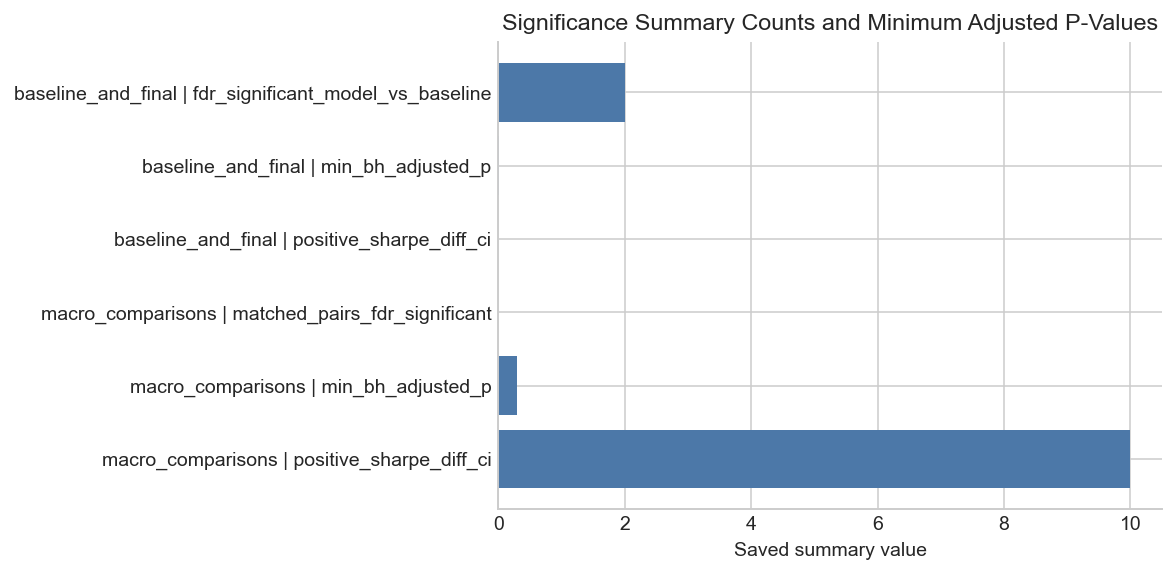

Saved: data\results\figures\final_significance_summary.png


In [15]:
plot_sig = final_sig.copy()
plot_sig["label"] = plot_sig["source"] + " | " + plot_sig["metric"]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.barh(plot_sig["label"].iloc[::-1], plot_sig["value"].iloc[::-1], color="#4c78a8")
ax.set_title("Significance Summary Counts and Minimum Adjusted P-Values")
ax.set_xlabel("Saved summary value")
ax.set_ylabel("")
fig.tight_layout()
sig_fig = FIGURES / "final_significance_summary.png"
fig.savefig(sig_fig, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved: {sig_fig.relative_to(ROOT)}")

The saved significance artifacts indicate that final model comparisons and macro-vs-baseline comparisons should be discussed cautiously. The weekly DM tests and block-bootstrap intervals are the basis for any statistical language in the paper.

## 9. Appendix: Exploratory Macro Variants

The following rows are intentionally excluded from headline tables because they are exploratory or not part of the final model roster. They are displayed here for auditability only.

In [16]:
appendix_rows = []
for source_name, df in [
    ("ML metrics", ml_metrics),
    ("Rank IC", rank_ic),
    ("Calibration", calibration),
]:
    subset = df[df["model"].isin(EXPLORATORY_MODELS)].copy()
    if subset.empty:
        continue
    subset.insert(0, "source", source_name)
    appendix_rows.append(subset)

if appendix_rows:
    display(Markdown("### Exploratory Model Rows"))
    for subset in appendix_rows:
        display(rounded(subset, 5))
else:
    display(Markdown("No exploratory model rows found in the saved artifacts."))

### Exploratory Model Rows

,source,model,mse,mae,r2,da
12,ML metrics,GNN-Correlation + Macro,0.03338,0.10734,0.11681,0.71642
15,ML metrics,LSTM + Macro,0.03484,0.12475,0.07814,0.67362


,source,model,mean_ic,ic_std,ic_tstat,ic_pvalue,ic_ir,n_weeks,pct_positive,top_quartile_hit_rate,pairwise_accuracy
0,Rank IC,LSTM + Macro,0.44701,0.10601,42.79455,0.0,4.21667,103,1.0,0.50737,0.65502
2,Rank IC,GNN-Correlation + Macro,0.43163,0.11167,39.22591,0.0,3.86504,103,1.0,0.49381,0.64230


,source,model,n_weeks,n_observations,prediction_mean,prediction_std,prediction_min,prediction_max,avg_weekly_prediction_spread_p90_p10,calibration_slope,calibration_intercept,pearson_corr,spearman_rank_ic
1,Calibration,GNN-Correlation + Macro,103,47895,0.22457,0.04652,0.17753,0.53868,0.08174,1.70470,-0.12998,0.40791,0.43163
15,Calibration,LSTM + Macro,103,47895,0.29620,0.11502,0.14215,1.70546,0.16509,0.68269,0.05062,0.40389,0.44701


## Output Manifest

The notebook wrote paper-facing CSVs under `data/results/` and PNG figures under `data/results/figures/`.

In [17]:
created_csvs = [
    "final_ml_metrics_table.csv",
    "final_rank_ic_table.csv",
    "final_calibration_summary.csv",
    "final_portfolio_inverse_vol_metrics.csv",
    "final_portfolio_long_short_metrics.csv",
    "final_portfolio_vol_target_metrics.csv",
    "final_portfolio_minvar_metrics.csv",
    "final_dm_test_summary.csv",
    "final_bootstrap_sharpe_summary.csv",
    "final_macro_vs_baseline_deltas.csv",
    "final_significance_summary.csv",
]
created_figures = [
    "final_test_mse_by_model.png",
    "final_rank_ic_by_model.png",
    "final_calibration_by_predicted_rv.png",
    "final_portfolio_cumulative_returns.png",
    "final_macro_vs_baseline_deltas.png",
    "final_significance_summary.png",
]
manifest = pd.DataFrame(
    {
        "artifact": created_csvs + created_figures,
        "path": [str((RESULTS / name).relative_to(ROOT)) for name in created_csvs]
        + [str((FIGURES / name).relative_to(ROOT)) for name in created_figures],
        "exists": [(RESULTS / name).exists() for name in created_csvs]
        + [(FIGURES / name).exists() for name in created_figures],
    }
)
display(manifest)
assert manifest["exists"].all(), "One or more final artifacts were not created."

,artifact,path,exists
0,final_ml_metrics_table.csv,data\results\final_ml_metrics_table.csv,True
1,final_rank_ic_table.csv,data\results\final_rank_ic_table.csv,True
2,final_calibration_summary.csv,data\results\final_calibration_summary.csv,True
3,final_portfolio_inverse_vol_metrics.csv,data\results\final_portfolio_inverse_vol_metri...,True
4,final_portfolio_long_short_metrics.csv,data\results\final_portfolio_long_short_metric...,True
5,final_portfolio_vol_target_metrics.csv,data\results\final_portfolio_vol_target_metric...,True
6,final_portfolio_minvar_metrics.csv,data\results\final_portfolio_minvar_metrics.csv,True
7,final_dm_test_summary.csv,data\results\final_dm_test_summary.csv,True
8,final_bootstrap_sharpe_summary.csv,data\results\final_bootstrap_sharpe_summary.csv,True
9,final_macro_vs_baseline_deltas.csv,data\results\final_macro_vs_baseline_deltas.csv,True
